# Cell 1：导入库

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

warnings.filterwarnings("ignore")

# Cell 2：设置路径

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
FIGURE_DIR = PROJECT_ROOT / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

factor_file = PROCESSED_DIR / "etf_factors_long.csv"

print("项目根目录:", PROJECT_ROOT)
print("因子数据文件:", factor_file)

项目根目录: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha
因子数据文件: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\etf_factors_long.csv


# Cell 3：读取因子数据

In [3]:
factor_data = pd.read_csv(factor_file, encoding="utf-8-sig")

factor_data["date"] = pd.to_datetime(factor_data["date"])

factor_data = factor_data.sort_values(["date", "symbol"]).reset_index(drop=True)

print("数据形状:", factor_data.shape)
print("ETF 数量:", factor_data["symbol"].nunique())
print("日期范围:", factor_data["date"].min(), "到", factor_data["date"].max())

factor_data.head()

数据形状: (25810, 32)
ETF 数量: 14
日期范围: 2018-01-02 00:00:00 到 2026-06-12 00:00:00


,date,open,high,low,close,volume,amount,amplitude,pct_change,change,...,future_return_20d,z_mom_5,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,alpha_score,alpha_rank,n_assets_on_date
0,2018-01-02,1.650,1.676,1.646,1.665,983128,163062394.0,1.82,1.28,0.021,...,0.013213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2018-01-02,3.428,3.480,3.426,3.478,1688766,695160736.0,1.58,1.76,0.060,...,0.048304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,2018-01-02,5.531,5.592,5.520,5.589,525743,349300160.0,1.31,1.38,0.076,...,-0.005368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2018-01-02,2.176,2.195,2.173,2.195,16427,1360313.0,1.01,1.11,0.024,...,-0.017312,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,2018-01-02,0.844,0.849,0.842,0.849,90641,7668141.0,0.83,0.83,0.007,...,-0.036514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


# Cell 4：检查必要字段

In [4]:
required_cols = [
    "date",
    "symbol",
    "name",
    "alpha_score",
    "alpha_rank",
    "future_return_1d",
    "future_return_5d",
    "future_return_20d",
]

missing_cols = [col for col in required_cols if col not in factor_data.columns]

if missing_cols:
    raise ValueError(f"缺失必要字段: {missing_cols}")
else:
    print("所有必要字段均存在，可以继续。")

所有必要字段均存在，可以继续。


# Cell 5：基础样本检查

In [5]:
analysis_data = factor_data.dropna(
    subset=[
        "alpha_score",
        "future_return_1d",
        "future_return_5d",
        "future_return_20d",
    ]
).copy()

sample_check = (
    analysis_data
    .groupby("date")
    .agg(
        n_assets=("symbol", "nunique"),
        alpha_non_missing=("alpha_score", "count"),
    )
    .reset_index()
)

print("可用于分析的数据形状:", analysis_data.shape)
print("有效交易日数量:", analysis_data["date"].nunique())
print("每日可用 ETF 数量统计:")
display(sample_check["n_assets"].describe())

analysis_data.head()

可用于分析的数据形状: (24681, 32)
有效交易日数量: 1966
每日可用 ETF 数量统计:


count    1966.000000
mean       12.553917
std         1.970235
min         9.000000
25%        11.000000
50%        14.000000
75%        14.000000
max        14.000000
Name: n_assets, dtype: float64

,date,open,high,low,close,volume,amount,amplitude,pct_change,change,...,future_return_20d,z_mom_5,z_mom_20,z_mom_60,z_vol_20,z_drawdown_20,z_amount_change_20,alpha_score,alpha_rank,n_assets_on_date
540,2018-04-03,1.765,1.778,1.744,1.764,6971305,1.229546e+09,1.90,-1.34,-0.024,...,-0.008503,0.615856,1.190037,2.039080,1.296939,0.874509,0.560433,1.263204,1.0,9
541,2018-04-03,3.247,3.266,3.225,3.246,1409853,5.433517e+08,1.25,-0.76,-0.025,...,-0.008318,-0.414449,-1.076218,-0.823177,-0.465883,-0.923757,-0.463507,-0.897683,9.0,9
542,2018-04-03,5.303,5.337,5.275,5.324,493660,3.133897e+08,1.15,-0.84,-0.045,...,-0.006198,0.219165,-0.029821,-0.385541,0.226599,0.188398,-1.087759,-0.282561,5.0,9
543,2018-04-03,2.108,2.108,2.080,2.094,15483,1.226110e+06,1.32,-1.18,-0.025,...,-0.014327,0.423143,0.360217,-0.353759,0.235817,0.520930,-1.047682,-0.045162,4.0,9
544,2018-04-03,0.859,0.865,0.845,0.858,319109,2.730463e+07,2.30,-1.15,-0.010,...,-0.012821,1.115722,1.595802,0.930636,1.003442,0.980336,0.589302,1.064884,2.0,9


# Cell 6：定义IC和Rank Ic计算函数

In [6]:
def calc_ic_for_one_day(df: pd.DataFrame, return_col: str) -> pd.Series:
    """
    计算单日横截面 IC 和 Rank IC。

    IC:
        corr(alpha_score, future_return)

    Rank IC:
        corr(rank(alpha_score), rank(future_return))
    """
    sub = df[["alpha_score", return_col]].dropna().copy()

    if len(sub) < 3:
        return pd.Series({
            "ic": np.nan,
            "rank_ic": np.nan,
            "n_assets": len(sub)
        })

    if sub["alpha_score"].std(ddof=0) == 0 or sub[return_col].std(ddof=0) == 0:
        return pd.Series({
            "ic": np.nan,
            "rank_ic": np.nan,
            "n_assets": len(sub)
        })

    ic = sub["alpha_score"].corr(sub[return_col], method="pearson")
    rank_ic = sub["alpha_score"].corr(sub[return_col], method="spearman")

    return pd.Series({
        "ic": ic,
        "rank_ic": rank_ic,
        "n_assets": len(sub)
    })

# Cell 7：计算不同预测窗口的每日IC

In [7]:
future_return_cols = [
    "future_return_1d",
    "future_return_5d",
    "future_return_20d",
]

daily_ic_list = []

for return_col in future_return_cols:
    temp = (
        analysis_data
        .groupby("date")
        .apply(lambda x: calc_ic_for_one_day(x, return_col))
        .reset_index()
    )

    temp["return_horizon"] = return_col
    daily_ic_list.append(temp)

daily_ic_report = pd.concat(daily_ic_list, ignore_index=True)

daily_ic_report = daily_ic_report[
    ["date", "return_horizon", "ic", "rank_ic", "n_assets"]
].sort_values(["return_horizon", "date"])

daily_ic_report.head()

,date,return_horizon,ic,rank_ic,n_assets
0,2018-04-03,future_return_1d,-0.465574,-0.400000,9.0
1,2018-04-04,future_return_1d,0.397270,-0.216667,9.0
2,2018-04-09,future_return_1d,-0.916595,-0.966667,9.0
3,2018-04-10,future_return_1d,0.303801,0.233333,9.0
4,2018-04-11,future_return_1d,0.224323,0.083333,9.0


# Cell 8：生成IC汇总表

In [8]:
def t_test_mean(series: pd.Series) -> tuple:
    """
    对均值是否显著不等于 0 做 t 检验。
    """
    x = series.dropna()

    if len(x) < 3:
        return np.nan, np.nan

    t_stat, p_value = stats.ttest_1samp(x, popmean=0)

    return t_stat, p_value


ic_summary_rows = []

for return_col in future_return_cols:
    sub = daily_ic_report[daily_ic_report["return_horizon"] == return_col].copy()

    ic_t, ic_p = t_test_mean(sub["ic"])
    rank_ic_t, rank_ic_p = t_test_mean(sub["rank_ic"])

    ic_summary_rows.append({
        "return_horizon": return_col,
        "ic_mean": sub["ic"].mean(),
        "ic_std": sub["ic"].std(),
        "ic_t_stat": ic_t,
        "ic_p_value": ic_p,
        "icir_daily": sub["ic"].mean() / sub["ic"].std() if sub["ic"].std() != 0 else np.nan,
        "rank_ic_mean": sub["rank_ic"].mean(),
        "rank_ic_std": sub["rank_ic"].std(),
        "rank_ic_t_stat": rank_ic_t,
        "rank_ic_p_value": rank_ic_p,
        "rank_icir_daily": sub["rank_ic"].mean() / sub["rank_ic"].std() if sub["rank_ic"].std() != 0 else np.nan,
        "n_days": sub["ic"].count(),
        "avg_n_assets": sub["n_assets"].mean(),
    })

ic_summary_report = pd.DataFrame(ic_summary_rows)

ic_summary_report

,return_horizon,ic_mean,ic_std,ic_t_stat,ic_p_value,icir_daily,rank_ic_mean,rank_ic_std,rank_ic_t_stat,rank_ic_p_value,rank_icir_daily,n_days,avg_n_assets
0,future_return_1d,0.020393,0.476302,1.898444,0.057784,0.042816,0.027697,0.433732,2.831377,0.004682,0.063857,1966,12.553917
1,future_return_5d,0.026801,0.473931,2.507445,0.012241,0.056551,0.027758,0.433910,2.836505,0.004608,0.063972,1966,12.553917
2,future_return_20d,0.047640,0.438460,4.817677,0.000002,0.108654,0.040491,0.403909,4.444968,0.000009,0.100248,1966,12.553917


# Cell 9：保存IC结果

In [9]:
daily_ic_file = PROCESSED_DIR / "daily_ic_report.csv"
ic_summary_file = PROCESSED_DIR / "ic_summary_report.csv"

daily_ic_report.to_csv(daily_ic_file, index=False, encoding="utf-8-sig")
ic_summary_report.to_csv(ic_summary_file, index=False, encoding="utf-8-sig")

print(f"已保存每日 IC 报告: {daily_ic_file}")
print(f"已保存 IC 汇总报告: {ic_summary_file}")

已保存每日 IC 报告: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\daily_ic_report.csv
已保存 IC 汇总报告: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\ic_summary_report.csv


# Cell 10：画IC时间序列图

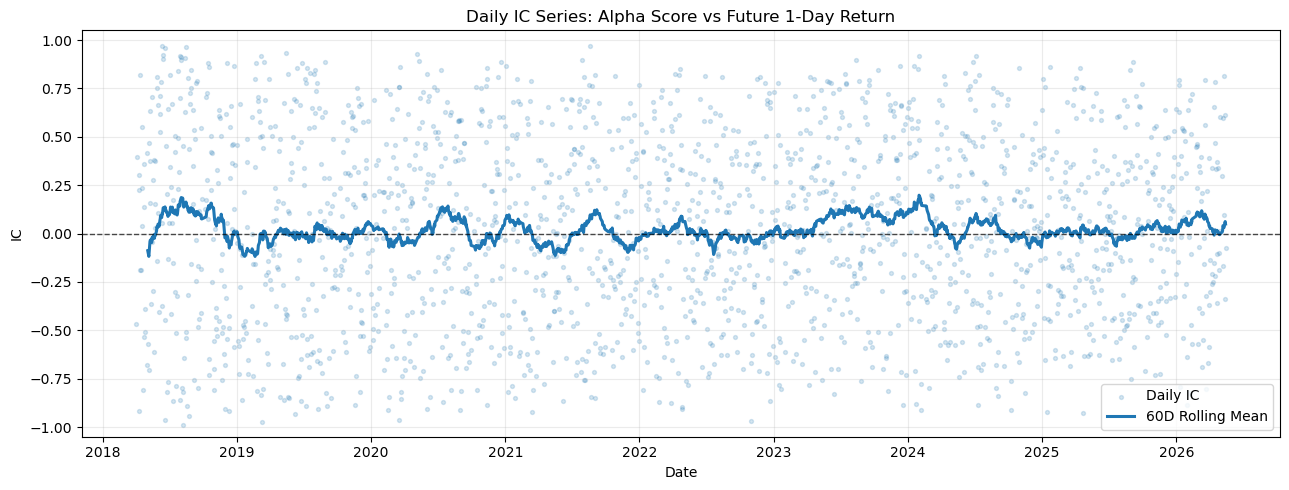

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\ic_series_1d.png


In [23]:
import matplotlib.dates as mdates

plot_horizon = "future_return_1d"

plot_data = daily_ic_report[daily_ic_report["return_horizon"] == plot_horizon].copy()
plot_data["date"] = pd.to_datetime(plot_data["date"])
plot_data = plot_data.sort_values("date")

smooth_window = 60
plot_data["ic_60d"] = plot_data["ic"].rolling(
    smooth_window,
    min_periods=20
).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(
    plot_data["date"],
    plot_data["ic"],
    s=8,
    alpha=0.18,
    label="Daily IC"
)

ax.plot(
    plot_data["date"],
    plot_data["ic_60d"],
    linewidth=2.2,
    label=f"{smooth_window}D Rolling Mean"
)

ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)

ax.set_title("Daily IC Series: Alpha Score vs Future 1-Day Return")
ax.set_xlabel("Date")
ax.set_ylabel("IC")
ax.set_ylim(-1.05, 1.05)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

ic_fig_file = FIGURE_DIR / "ic_series_1d.png"
fig.savefig(ic_fig_file, dpi=300)
plt.show()

print(f"已保存图像: {ic_fig_file}")


# Cell 11：画Rank IC时间序列图

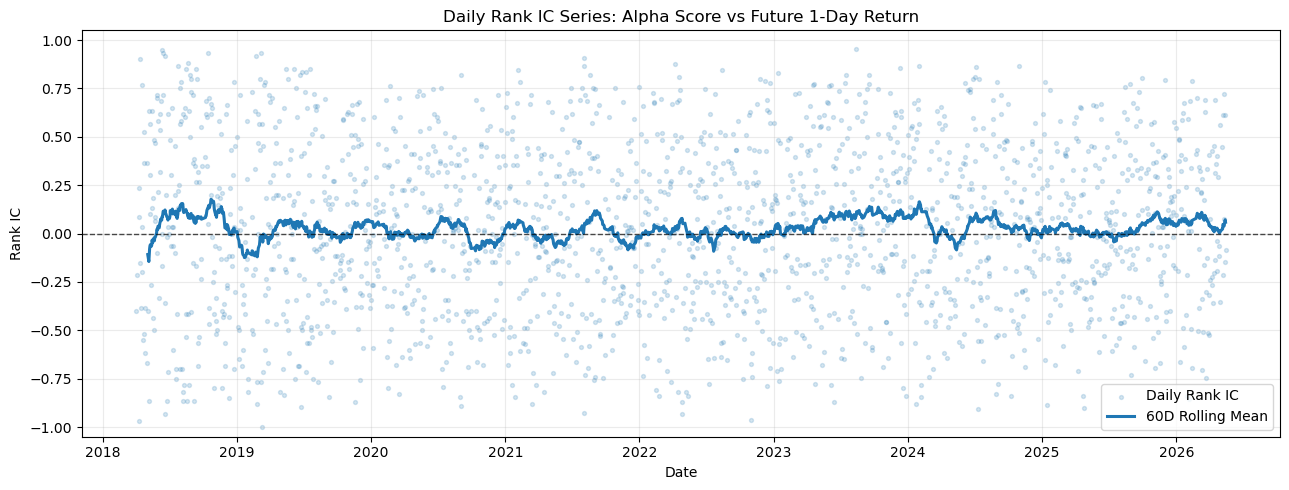

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\rank_ic_series_1d.png


In [24]:
plot_data["rank_ic_60d"] = plot_data["rank_ic"].rolling(
    smooth_window,
    min_periods=20
).mean()

fig, ax = plt.subplots(figsize=(13, 5))

ax.scatter(
    plot_data["date"],
    plot_data["rank_ic"],
    s=8,
    alpha=0.18,
    label="Daily Rank IC"
)

ax.plot(
    plot_data["date"],
    plot_data["rank_ic_60d"],
    linewidth=2.2,
    label=f"{smooth_window}D Rolling Mean"
)

ax.axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.7)

ax.set_title("Daily Rank IC Series: Alpha Score vs Future 1-Day Return")
ax.set_xlabel("Date")
ax.set_ylabel("Rank IC")
ax.set_ylim(-1.05, 1.05)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()

rank_ic_fig_file = FIGURE_DIR / "rank_ic_series_1d.png"
fig.savefig(rank_ic_fig_file, dpi=300)
plt.show()

print(f"已保存图像: {rank_ic_fig_file}")

# Cell：12 定义分组函数

In [12]:
def assign_alpha_group(df: pd.DataFrame) -> pd.DataFrame:
    """
    根据每日 alpha_score 排名分组。

    由于 ETF 数量较少，使用三组：
    - Low Alpha: 底部 30%
    - Middle Alpha: 中间 40%
    - High Alpha: 顶部 30%
    """
    df = df.copy()
    df = df.dropna(subset=["alpha_score"])

    n = len(df)

    if n < 3:
        df["alpha_group"] = np.nan
        return df

    df["rank_pct"] = df["alpha_score"].rank(ascending=True, method="first") / n

    conditions = [
        df["rank_pct"] <= 0.3,
        (df["rank_pct"] > 0.3) & (df["rank_pct"] < 0.7),
        df["rank_pct"] >= 0.7,
    ]

    choices = [
        "Low Alpha",
        "Middle Alpha",
        "High Alpha",
    ]

    df["alpha_group"] = np.select(conditions, choices, default=np.nan)

    return df


grouped_data = (
    analysis_data
    .groupby("date", group_keys=False)
    .apply(assign_alpha_group)
    .reset_index(drop=True)
)

grouped_data[["date", "symbol", "name", "alpha_score", "rank_pct", "alpha_group"]].dropna().head(20)

,date,symbol,name,alpha_score,rank_pct,alpha_group
0,2018-04-03,159915,创业板ETF,1.263204,1.000000,High Alpha
1,2018-04-03,510300,沪深300ETF,-0.897683,0.111111,Low Alpha
2,2018-04-03,510500,中证500ETF,-0.282561,0.555556,Middle Alpha
3,2018-04-03,512100,中证1000ETF,-0.045162,0.666667,Middle Alpha
4,2018-04-03,512660,军工ETF,1.064884,0.888889,High Alpha
5,2018-04-03,512880,证券ETF,-0.435705,0.444444,Middle Alpha
6,2018-04-03,513100,纳指ETF,-0.879945,0.222222,Low Alpha
7,2018-04-03,513500,标普500ETF,-0.723641,0.333333,Middle Alpha
8,2018-04-03,518880,黄金ETF,0.936608,0.777778,High Alpha
9,2018-04-04,159915,创业板ETF,0.907169,0.777778,High Alpha


# Cell 13：计算每日分组未来收益

In [13]:
group_return_list = []

for return_col in future_return_cols:
    temp = (
        grouped_data
        .dropna(subset=["alpha_group", return_col])
        .groupby(["date", "alpha_group"])
        .agg(
            group_future_return=(return_col, "mean"),
            n_assets=("symbol", "nunique")
        )
        .reset_index()
    )

    temp["return_horizon"] = return_col
    group_return_list.append(temp)

group_return_daily = pd.concat(group_return_list, ignore_index=True)

group_return_daily.head()

,date,alpha_group,group_future_return,n_assets,return_horizon
0,2018-04-03,High Alpha,-0.007315,3,future_return_1d
1,2018-04-03,Low Alpha,-0.000364,2,future_return_1d
2,2018-04-03,Middle Alpha,-0.005294,4,future_return_1d
3,2018-04-04,High Alpha,0.009694,3,future_return_1d
4,2018-04-04,Low Alpha,0.004294,2,future_return_1d


# Cell 14：生成分组收益汇总表

In [14]:
group_return_summary = (
    group_return_daily
    .groupby(["return_horizon", "alpha_group"])
    .agg(
        mean_future_return=("group_future_return", "mean"),
        std_future_return=("group_future_return", "std"),
        n_days=("group_future_return", "count"),
        avg_n_assets=("n_assets", "mean"),
    )
    .reset_index()
)

group_order = ["Low Alpha", "Middle Alpha", "High Alpha"]

group_return_summary["alpha_group"] = pd.Categorical(
    group_return_summary["alpha_group"],
    categories=group_order,
    ordered=True
)

group_return_summary = group_return_summary.sort_values(
    ["return_horizon", "alpha_group"]
)

group_return_summary

,return_horizon,alpha_group,mean_future_return,std_future_return,n_days,avg_n_assets
1,future_return_1d,Low Alpha,0.000302,0.015426,1966,3.452187
2,future_return_1d,Middle Alpha,0.000475,0.013973,1966,4.649542
0,future_return_1d,High Alpha,0.000703,0.013675,1966,4.452187
4,future_return_20d,Low Alpha,0.009909,0.071939,1966,3.452187
5,future_return_20d,Middle Alpha,0.008662,0.065749,1966,4.649542
3,future_return_20d,High Alpha,0.011521,0.059210,1966,4.452187
7,future_return_5d,Low Alpha,0.002073,0.035232,1966,3.452187
8,future_return_5d,Middle Alpha,0.002184,0.033007,1966,4.649542
6,future_return_5d,High Alpha,0.003318,0.029668,1966,4.452187


# Cell 15：计算高低Alpha

In [16]:
group_pivot_list = []

for return_col in future_return_cols:
    temp = group_return_daily[group_return_daily["return_horizon"] == return_col].copy()

    pivot = temp.pivot(
        index="date",
        columns="alpha_group",
        values="group_future_return"
    )

    pivot["High_minus_Low"] = pivot["High Alpha"] - pivot["Low Alpha"]
    pivot["return_horizon"] = return_col

    group_pivot_list.append(pivot.reset_index())

high_minus_low_daily = pd.concat(group_pivot_list, ignore_index=True)

high_minus_low_daily.head()

alpha_group,date,High Alpha,Low Alpha,Middle Alpha,High_minus_Low,return_horizon
0,2018-04-03,-0.007315,-0.000364,-0.005294,-0.006951,future_return_1d
1,2018-04-04,0.009694,0.004294,0.002769,0.005400,future_return_1d
2,2018-04-09,-0.009681,0.020895,0.009479,-0.030576,future_return_1d
3,2018-04-10,0.002559,0.000754,0.000266,0.001805,future_return_1d
4,2018-04-11,-0.004127,-0.004459,-0.006125,0.000332,future_return_1d


# Cell 16：High-Low汇总检验

In [17]:
high_minus_low_rows = []

for return_col in future_return_cols:
    sub = high_minus_low_daily[
        high_minus_low_daily["return_horizon"] == return_col
    ].copy()

    x = sub["High_minus_Low"].dropna()

    if len(x) >= 3:
        t_stat, p_value = stats.ttest_1samp(x, popmean=0)
    else:
        t_stat, p_value = np.nan, np.nan

    high_minus_low_rows.append({
        "return_horizon": return_col,
        "mean_high_minus_low": x.mean(),
        "std_high_minus_low": x.std(),
        "t_stat": t_stat,
        "p_value": p_value,
        "positive_ratio": (x > 0).mean(),
        "n_days": len(x),
    })

high_minus_low_report = pd.DataFrame(high_minus_low_rows)

high_minus_low_report

,return_horizon,mean_high_minus_low,std_high_minus_low,t_stat,p_value,positive_ratio,n_days
0,future_return_1d,0.000401,0.014515,1.224985,0.220728,0.530519,1966
1,future_return_5d,0.001246,0.030900,1.787509,0.074009,0.526958,1966
2,future_return_20d,0.001613,0.058100,1.230656,0.218599,0.525941,1966


# Cell 17：保存分组收益结果

In [18]:
group_return_daily_file = PROCESSED_DIR / "group_return_daily.csv"
group_return_summary_file = PROCESSED_DIR / "group_return_summary.csv"
high_minus_low_file = PROCESSED_DIR / "high_minus_low_report.csv"

group_return_daily.to_csv(group_return_daily_file, index=False, encoding="utf-8-sig")
group_return_summary.to_csv(group_return_summary_file, index=False, encoding="utf-8-sig")
high_minus_low_report.to_csv(high_minus_low_file, index=False, encoding="utf-8-sig")

print(f"已保存每日分组收益: {group_return_daily_file}")
print(f"已保存分组收益汇总: {group_return_summary_file}")
print(f"已保存 High - Low 报告: {high_minus_low_file}")

已保存每日分组收益: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\group_return_daily.csv
已保存分组收益汇总: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\group_return_summary.csv
已保存 High - Low 报告: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\high_minus_low_report.csv


# Cell 18：画1日未来收益的分组柱状图

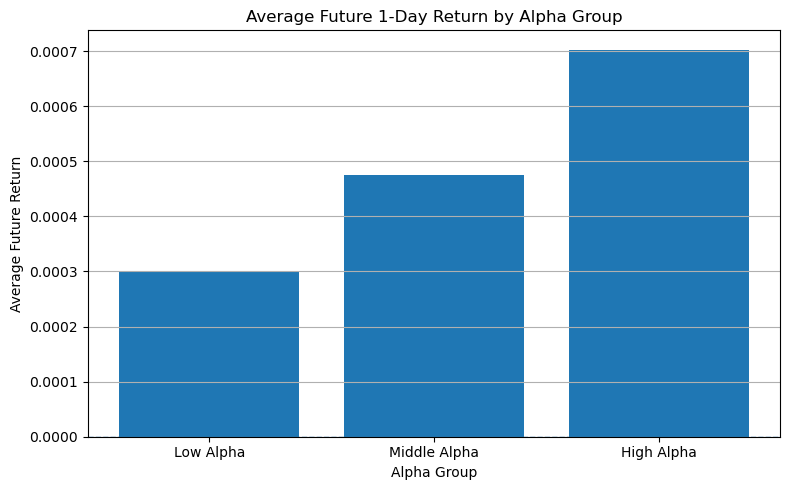

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\group_return_bar_1d.png


In [19]:
plot_horizon = "future_return_1d"

plot_group = group_return_summary[
    group_return_summary["return_horizon"] == plot_horizon
].copy()

plot_group = plot_group.sort_values("alpha_group")

plt.figure(figsize=(8, 5))
plt.bar(
    plot_group["alpha_group"].astype(str),
    plot_group["mean_future_return"]
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Average Future 1-Day Return by Alpha Group")
plt.xlabel("Alpha Group")
plt.ylabel("Average Future Return")
plt.grid(axis="y")
plt.tight_layout()

group_bar_file = FIGURE_DIR / "group_return_bar_1d.png"
plt.savefig(group_bar_file, dpi=300)
plt.show()

print(f"已保存图像: {group_bar_file}")

# Cell 19：画High-Low累计收益图

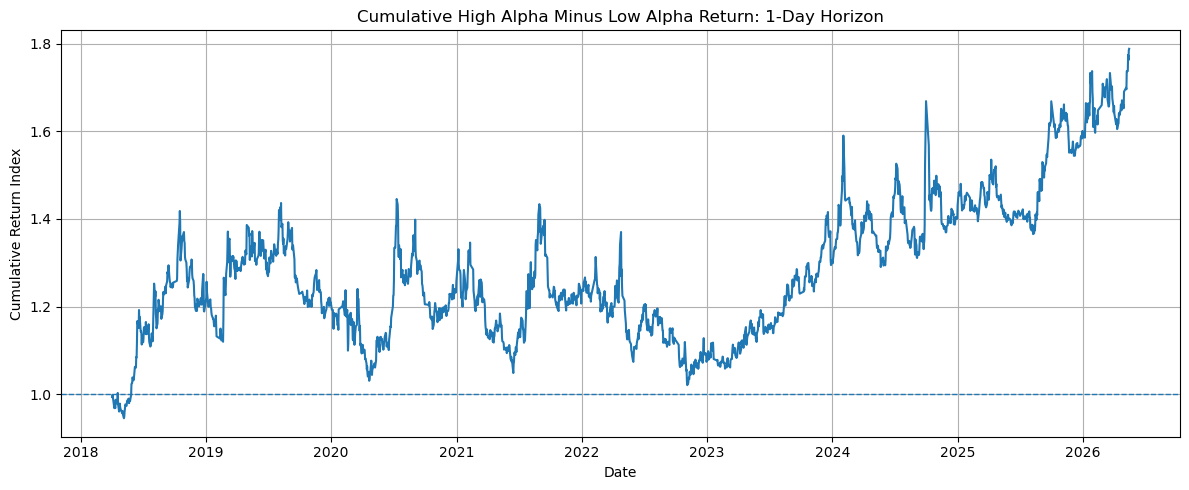

已保存图像: C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\high_minus_low_cumulative_1d.png


In [20]:
plot_hl = high_minus_low_daily[
    high_minus_low_daily["return_horizon"] == "future_return_1d"
].copy()

plot_hl = plot_hl.sort_values("date")
plot_hl["cum_high_minus_low"] = (1 + plot_hl["High_minus_Low"].fillna(0)).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(plot_hl["date"], plot_hl["cum_high_minus_low"])
plt.axhline(1, linestyle="--", linewidth=1)
plt.title("Cumulative High Alpha Minus Low Alpha Return: 1-Day Horizon")
plt.xlabel("Date")
plt.ylabel("Cumulative Return Index")
plt.grid(True)
plt.tight_layout()

hl_cum_file = FIGURE_DIR / "high_minus_low_cumulative_1d.png"
plt.savefig(hl_cum_file, dpi=300)
plt.show()

print(f"已保存图像: {hl_cum_file}")

# Cell 20：输出最终辅助结论表

In [21]:
print("IC Summary")
display(ic_summary_report)

print("Group Return Summary")
display(group_return_summary)

print("High Minus Low Report")
display(high_minus_low_report)

IC Summary


,return_horizon,ic_mean,ic_std,ic_t_stat,ic_p_value,icir_daily,rank_ic_mean,rank_ic_std,rank_ic_t_stat,rank_ic_p_value,rank_icir_daily,n_days,avg_n_assets
0,future_return_1d,0.020393,0.476302,1.898444,0.057784,0.042816,0.027697,0.433732,2.831377,0.004682,0.063857,1966,12.553917
1,future_return_5d,0.026801,0.473931,2.507445,0.012241,0.056551,0.027758,0.433910,2.836505,0.004608,0.063972,1966,12.553917
2,future_return_20d,0.047640,0.438460,4.817677,0.000002,0.108654,0.040491,0.403909,4.444968,0.000009,0.100248,1966,12.553917


Group Return Summary


,return_horizon,alpha_group,mean_future_return,std_future_return,n_days,avg_n_assets
1,future_return_1d,Low Alpha,0.000302,0.015426,1966,3.452187
2,future_return_1d,Middle Alpha,0.000475,0.013973,1966,4.649542
0,future_return_1d,High Alpha,0.000703,0.013675,1966,4.452187
4,future_return_20d,Low Alpha,0.009909,0.071939,1966,3.452187
5,future_return_20d,Middle Alpha,0.008662,0.065749,1966,4.649542
3,future_return_20d,High Alpha,0.011521,0.059210,1966,4.452187
7,future_return_5d,Low Alpha,0.002073,0.035232,1966,3.452187
8,future_return_5d,Middle Alpha,0.002184,0.033007,1966,4.649542
6,future_return_5d,High Alpha,0.003318,0.029668,1966,4.452187


High Minus Low Report


,return_horizon,mean_high_minus_low,std_high_minus_low,t_stat,p_value,positive_ratio,n_days
0,future_return_1d,0.000401,0.014515,1.224985,0.220728,0.530519,1966
1,future_return_5d,0.001246,0.030900,1.787509,0.074009,0.526958,1966
2,future_return_20d,0.001613,0.058100,1.230656,0.218599,0.525941,1966



# Cell 21：最终检查

In [22]:
print("第三部分完成。")
print("=" * 60)

print("输出文件:")
print(daily_ic_file)
print(ic_summary_file)
print(group_return_daily_file)
print(group_return_summary_file)
print(high_minus_low_file)

print("=" * 60)

print("输出图像:")
print(ic_fig_file)
print(rank_ic_fig_file)
print(group_bar_file)
print(hl_cum_file)

print("=" * 60)

print("有效样本数:", len(analysis_data))
print("有效日期数:", analysis_data["date"].nunique())
print("ETF 数量:", analysis_data["symbol"].nunique())

第三部分完成。
输出文件:
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\daily_ic_report.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\ic_summary_report.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\group_return_daily.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\group_return_summary.csv
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\data\processed\high_minus_low_report.csv
输出图像:
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\ic_series_1d.png
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\rank_ic_series_1d.png
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\group_return_bar_1d.png
C:\Users\曾鸣\Desktop\daily-etf-cross-sectional-alpha\figures\high_minus_low_cumulative_1d.png
有效样本数: 24681
有效日期数: 1966
ETF 数量: 14
